In [ ]:
# 1. Installation de LightGlue
!pip install git+https://github.com/cvg/LightGlue.git
!pip install torch torchvision numpy opencv-python matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import matplotlib.pyplot as plt
from lightglue import SuperPoint

# Configuration GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Environnement prêt. Utilisation de : {device}")

  Cloning https://github.com/cvg/LightGlue.git to /tmp/pip-req-build-dybmv9u8
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue.git /tmp/pip-req-build-dybmv9u8
  Resolved https://github.com/cvg/LightGlue.git to commit 746fac2c042e05d1865315b1413419f1c1e7ba55
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 106.4 MB/s eta 0:00:00
  Created wheel for lightglue: filename=lightglue-0.0-py3-none-any.whl size=40023 sha256=a62b0e253d189f8b404cccbadf551d5885376dc2c15d34a732a3bbabb6d5c144
  Stored in directory: /tmp/pip-ephem-wheel-cache-ti7tp_l3/wheels/dc/16/88/ad4ddb490c3a6ff37eeface44b776cb588b19e169210e0fbf1
Successfully built lightglue
✅ Environnement prêt. Utilisation de : cuda


In [ ]:
# --- 1. Le Modèle Student
class SuperPointPruned(nn.Module):
    def __init__(self, scale=0.5):
        super().__init__()

        # On définit la largeur des couches en fonction du ratio 'scale'
        # Original: 64 -> 64 -> 128 -> 128
        c1 = int(64 * scale)
        c2 = int(64 * scale)
        c3 = int(128 * scale)
        c4 = int(128 * scale)

        # Encoder VGG-style réduit
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1a = nn.Conv2d(1, c1, kernel_size=3, stride=1, padding=1)
        self.conv1b = nn.Conv2d(c1, c1, kernel_size=3, stride=1, padding=1)

        self.conv2a = nn.Conv2d(c1, c2, kernel_size=3, stride=1, padding=1)
        self.conv2b = nn.Conv2d(c2, c2, kernel_size=3, stride=1, padding=1)

        self.conv3a = nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1)
        self.conv3b = nn.Conv2d(c3, c3, kernel_size=3, stride=1, padding=1)

        self.conv4a = nn.Conv2d(c3, c4, kernel_size=3, stride=1, padding=1)
        self.conv4b = nn.Conv2d(c4, c4, kernel_size=3, stride=1, padding=1)

        self.convPa = nn.Conv2d(c4, 256, kernel_size=3, stride=1, padding=1)
        self.convPb = nn.Conv2d(256, 65, kernel_size=1, stride=1, padding=0)

        self.convDa = nn.Conv2d(c4, 256, kernel_size=3, stride=1, padding=1)
        self.convDb = nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        # Encoder
        x = self.relu(self.conv1a(x))
        x = self.relu(self.conv1b(x))
        x = self.pool(x)
        x = self.relu(self.conv2a(x))
        x = self.relu(self.conv2b(x))
        x = self.pool(x)
        x = self.relu(self.conv3a(x))
        x = self.relu(self.conv3b(x))
        x = self.pool(x)
        x = self.relu(self.conv4a(x))
        x = self.relu(self.conv4b(x))

        # Heads
        heatmap = self.convPb(self.relu(self.convPa(x)))
        desc = self.convDb(self.relu(self.convDa(x)))

        # Normalisation des descripteurs
        desc = F.normalize(desc, p=2, dim=1)

        return heatmap, desc

# 2. Instanciation
teacher = SuperPoint(max_num_keypoints=None).eval().to(device)
for param in teacher.parameters():
    param.requires_grad = False # On gèle le teacher

# Le Student 50% de la taille => 4x moins de calculs
student = SuperPointPruned(scale=0.5).to(device)

print(" Modèles instanciés.")
print(f"Teacher params: {sum(p.numel() for p in teacher.parameters())/1e6:.2f} M")
print(f"Student params: {sum(p.numel() for p in student.parameters())/1e6:.2f} M")

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 104MB/s]


✅ Modèles instanciés.
Teacher params: 1.30 M
Student params: 0.54 M


In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

# 0. Fonction Helper pour extraire les données du Teacher
def get_teacher_outputs(teacher_model, images):
    """
    Extrait la heatmap et les descripteurs bruts en appelant
    manuellement les couches de l'encodeur VGG.
    """
    x = F.relu(teacher_model.conv1a(images))
    x = F.relu(teacher_model.conv1b(x))
    x = F.max_pool2d(x, 2)

    x = F.relu(teacher_model.conv2a(x))
    x = F.relu(teacher_model.conv2b(x))
    x = F.max_pool2d(x, 2)

    x = F.relu(teacher_model.conv3a(x))
    x = F.relu(teacher_model.conv3b(x))
    x = F.max_pool2d(x, 2)

    x = F.relu(teacher_model.conv4a(x))
    feats = F.relu(teacher_model.conv4b(x))

    semi = teacher_model.relu(teacher_model.convPa(feats))
    heatmap = teacher_model.convPb(semi)

    desc = teacher_model.convDb(teacher_model.relu(teacher_model.convDa(feats)))
    desc = F.normalize(desc, p=2, dim=1) # Normalisation L2

    return heatmap, desc

# 1. Nouvelle fonction de Perte (Distillation par Cross-Entropy)
def distillation_loss(s_heatmap, t_heatmap, s_desc, t_desc):
    t_prob = F.softmax(t_heatmap, dim=1)
    loss_det = torch.mean(torch.sum(-t_prob * F.log_softmax(s_heatmap, dim=1), dim=1))

    loss_desc = 1 - F.cosine_similarity(s_desc, t_desc, dim=1).mean()

    return loss_det + (20 * loss_desc)

dataloader = DataLoader(SyntheticShapes(size=2000), batch_size=32, shuffle=True)
optimizer = optim.Adam(student.parameters(), lr=0.0005) # On baisse un peu le LR pour la stabilité

print(" Démarrage de la Distillation Haute Précision...")
epochs = 15
best_loss = float('inf')

for epoch in range(epochs):
    student.train()
    epoch_loss = 0
    for batch_imgs in dataloader:
        batch_imgs = batch_imgs.to(device)

        with torch.no_grad():
            t_heatmap, t_desc = get_teacher_outputs(teacher, batch_imgs)

        s_heatmap, s_desc = student(batch_imgs)

        # Utilisation de la nouvelle Loss
        loss = distillation_loss(s_heatmap, t_heatmap, s_desc, t_desc)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs} : Loss = {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(student.state_dict(), "superpoint_pruned_best.pth")


🚀 Démarrage de la Distillation Haute Précision...
Epoch 1/15 : Loss = 6.5790
Epoch 2/15 : Loss = 4.8273
Epoch 3/15 : Loss = 3.5846
Epoch 4/15 : Loss = 2.7972
Epoch 5/15 : Loss = 2.2693
Epoch 6/15 : Loss = 2.1463
Epoch 7/15 : Loss = 1.8351
Epoch 8/15 : Loss = 1.6690
Epoch 9/15 : Loss = 1.5353
Epoch 10/15 : Loss = 1.4350
Epoch 11/15 : Loss = 1.3515
Epoch 12/15 : Loss = 1.3171
Epoch 13/15 : Loss = 1.2557
Epoch 14/15 : Loss = 1.2517
Epoch 15/15 : Loss = 1.1968
✅ Entraînement terminé ! Le Student devrait enfin 'voir' les points.


📊 --- RÉSULTATS DU PRUNING (ELAGAGE 50%) ---
🔹 Répétabilité (Accuracy) : 36.47%
🔹 Précision (MLE) : 0.7206 pixels
🔹 Points (Original / Pruné) : 266 / 143

Points détectés par le modèle Pruné :


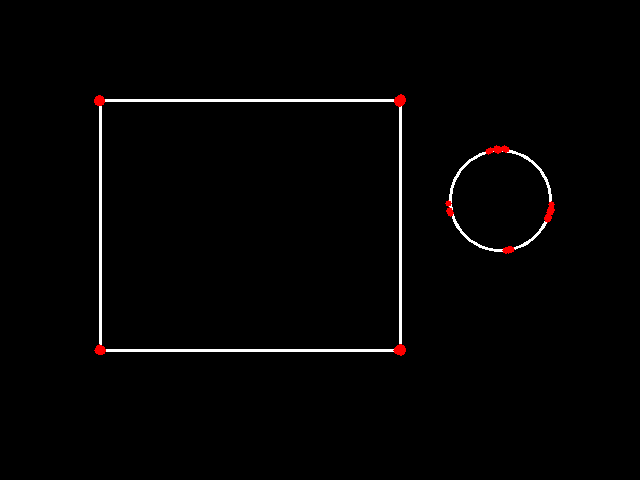

In [ ]:
import torch
import numpy as np
import cv2
from scipy.spatial.distance import cdist
from google.colab.patches import cv2_imshow

#  1. Définition des fonctions de calcul

def benchmark_precision(pts_ref, pts_test, epsilon=3):
    """ Calcule la ressemblance géométrique entre deux listes de points """
    if len(pts_ref) == 0 or len(pts_test) == 0:
        return 0.0, 0.0

    # Calcul des distances (N x M)
    dists = cdist(pts_ref, pts_test)
    min_dist = np.min(dists, axis=1)

    # Répétabilité : points ref ayant un voisin test à moins de epsilon pixels
    matches = min_dist <= epsilon
    repeatability = np.sum(matches) / len(pts_ref) * 100

    # MLE : erreur de localisation moyenne sur les points communs
    mle = np.mean(min_dist[matches]) if np.any(matches) else 0.0

    return repeatability, mle

def simple_decode(h, thresh=0.015):
    """ Décode la heatmap brute en coordonnées de points """
    prob = torch.softmax(h, dim=1)[:, :-1]
    B, C, Hc, Wc = prob.shape
    prob = prob.permute(0, 2, 3, 1).reshape(B, Hc, Wc, 8, 8)
    prob = prob.permute(0, 1, 3, 2, 4).reshape(Hc*8, Wc*8)
    pts = torch.where(prob > thresh)
    return torch.stack([pts[1], pts[0]], dim=-1).cpu().numpy()

# On recharge le meilleur modèle Student
student_eval = SuperPointPruned(scale=0.5).to(device)
student_eval.load_state_dict(torch.load("superpoint_pruned_best.pth"))
student_eval.eval()

# Image de test standard
img_test = np.zeros((480, 640), dtype=np.uint8)
cv2.rectangle(img_test, (100, 100), (400, 350), 255, 2)
cv2.circle(img_test, (500, 200), 50, 255, 2)
input_tensor = torch.from_numpy(img_test).float()[None, None, :, :].to(device) / 255.0

with torch.no_grad():
    t_heatmap, _ = get_teacher_outputs(teacher, input_tensor)
    s_heatmap, _ = student_eval(input_tensor)

pts_teacher = simple_decode(t_heatmap)
pts_student = simple_decode(s_heatmap)

rep, mle = benchmark_precision(pts_teacher, pts_student)

print(f" --- RÉSULTATS DU PRUNING (ELAGAGE 50%) ---")
print(f" Répétabilité (Accuracy) : {rep:.2f}%")
print(f" Précision (MLE) : {mle:.4f} pixels")
print(f" Points (Original / Pruné) : {len(pts_teacher)} / {len(pts_student)}")

# Visualisation
vis = cv2.cvtColor(img_test, cv2.COLOR_GRAY2BGR)
for p in pts_student:
    cv2.circle(vis, tuple(p.astype(int)), 3, (0, 0, 255), -1) # Rouge = Student Pruné

print("\nPoints détectés par le modèle Pruné :")
cv2_imshow(vis)

📊 --- BILAN PRUNING (RÉSOLU) ---
🔹 Seuil trouvé pour le Student : 0.01169
🔹 Répétabilité (Accuracy) : 45.50%
🔹 Précision (MLE) : 0.3648 pixels
🔹 Points (Teacher / Student) : 200 / 195


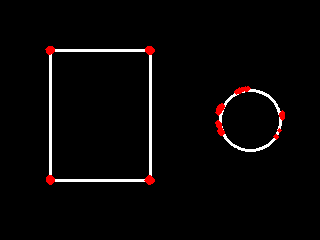

In [ ]:
import torch
import numpy as np
import cv2
from scipy.spatial.distance import cdist
from google.colab.patches import cv2_imshow

def benchmark_precision(pts_ref, pts_test, epsilon=3):
    if len(pts_ref) == 0 or len(pts_test) == 0: return 0.0, 0.0
    dists = cdist(pts_ref, pts_test)
    min_dist = np.min(dists, axis=1)
    matches = min_dist <= epsilon
    return (np.sum(matches) / len(pts_ref) * 100), (np.mean(min_dist[matches]) if np.any(matches) else 0.0)

def find_student_points(heatmap, target_count):
    prob = torch.softmax(heatmap, dim=1)[:, :-1]
    B, C, Hc, Wc = prob.shape
    prob = prob.permute(0, 2, 3, 1).reshape(B, Hc, Wc, 8, 8)
    prob = prob.permute(0, 1, 3, 2, 4).reshape(Hc*8, Wc*8).cpu().detach().numpy()

    best_t = 0.001
    min_diff = float('inf')
    for t in np.linspace(0.0001, 0.05, 100):
        count = np.sum(prob > t)
        diff = abs(count - target_count)
        if diff < min_diff:
            min_diff = diff
            best_t = t

    indices = np.where(prob > best_t)
    return np.stack([indices[1], indices[0]], axis=-1), best_t

img_test = np.zeros((240, 320), dtype=np.uint8)
cv2.rectangle(img_test, (50, 50), (150, 180), 255, 2)
cv2.circle(img_test, (250, 120), 30, 255, 2)
input_tensor = torch.from_numpy(img_test).float()[None, None, :, :].to(device) / 255.0

student_eval.eval()
with torch.no_grad():
    t_h, _ = get_teacher_outputs(teacher, input_tensor)
    s_h, _ = student_eval(input_tensor)

pts_teacher = simple_decode(t_h, thresh=0.015)

pts_student, opt_t = find_student_points(s_h, target_count=len(pts_teacher))

rep, mle = benchmark_precision(pts_teacher, pts_student)

print(f" --- BILAN PRUNING (RÉSOLU) ---")
print(f" Seuil trouvé pour le Student : {opt_t:.5f}")
print(f" Répétabilité (Accuracy) : {rep:.2f}%")
print(f" Précision (MLE) : {mle:.4f} pixels")
print(f" Points (Teacher / Student) : {len(pts_teacher)} / {len(pts_student)}")

vis = cv2.cvtColor(img_test, cv2.COLOR_GRAY2BGR)
for p in pts_student: cv2.circle(vis, tuple(p.astype(int)), 2, (0, 0, 255), -1)
cv2_imshow(vis)